In [19]:
import dill as pickle
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import os

from aero_optim.mf_sm.mf_infill import compute_pareto
from aero_optim.geom import get_area, get_camber_th, get_circle, get_chords, get_cog, split_profile

from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from pymoo.indicators.hv import HV
from scipy.spatial.distance import cdist

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Times",
    "figure.dpi": 300,
    "font.size": 8,
    'legend.fontsize': 8, 
    "axes.titlesize": 8,
    "axes.labelsize": 8
})

def get_valid_center(
        x: np.ndarray, y: np.ndarray, dmin: float, dmax: float,
        le: bool = True, percent: float = 10, resolution: int = 50
) -> np.ndarray | None:
    """
    **Computes** and **returns** the center of a valid circle in regards of the
    leading/trailing edge constraints.

    In particular, it checks if circles of radius dmin can fit in both the leading
    and trailing edges, and if such circles have their centers located at a distance
    to the leading/trailing edge that is smaller than dmax.
    **Returns** None if the constraint is not respected.
    """
    # sort coordinates
    count = int(len(x) * percent / 100)
    indices = np.argsort(x) if le else np.argsort(x)[::-1]
    x_sorted = x[indices][:count]
    y_sorted = y[indices][:count]

    # find bounding box for circle center location search
    profile = np.column_stack([x_sorted, y_sorted])
    min_x, min_y = profile.min(axis=0)
    max_x, max_y = profile.max(axis=0)

    # generate grid of candidate points, starting near leading edge
    x_vals = np.linspace(min_x, max_x, resolution)
    y_vals = np.linspace(min_y, max_y, resolution)
    X, Y = np.meshgrid(x_vals, y_vals)
    candidate_points = np.vstack([X.ravel(), Y.ravel()]).T

    # sort candidates by smallest x and on the right side of the le/te edge
    candidate_points = candidate_points[np.argsort(candidate_points[:, 0])]
    candidate_points = (
        candidate_points[candidate_points[:, 0] > profile[0, 0]] if le
        else candidate_points[candidate_points[:, 0] < profile[0, 0]]
    )

    # keep only the candidates at a distance from the le/te edge
    # comprised between dmin and dmax
    dists = cdist(candidate_points, np.array([[x_sorted[0], y_sorted[0]]]))
    idx, _ = np.where((dists > dmin) & (dists < dmax))

    # check if there is at least one pt that gives a valid circle center
    for pt in candidate_points[idx]:
        if np.min(cdist([pt], profile)) > dmin:
            return pt
    return None

def check_feasibility(baseline_profile: np.ndarray, profile: np.ndarray) -> bool:
    # baseline
    bsl_pts = baseline_profile
    bsl_c, bsl_c_ax = get_chords(bsl_pts)
    bsl_upper, bsl_lower = split_profile(bsl_pts)
    bsl_camber_th = get_camber_th(bsl_upper, bsl_lower, interpolate=True)
    bsl_th_over_c = bsl_camber_th[1] / bsl_c
    bsl_Xth_over_cax = bsl_camber_th[2] / bsl_c_ax
    bsl_area = get_area(bsl_pts)
    bsl_area_over_c2 = bsl_area / bsl_c**2
    bsl_cog = get_cog(bsl_pts)
    bsl_Xcg_over_cax = bsl_cog[0] / bsl_c_ax

    upper, lower = split_profile(profile)
    c, c_ax = get_chords(profile)
    camber_line, thmax, Xthmax, th_vec = get_camber_th(upper, lower, interpolate=True)
    th_over_c = thmax / c
    Xth_over_cax = Xthmax / c_ax
    th_cond = abs(th_over_c - bsl_th_over_c) / bsl_th_over_c - 0.3
    Xth_cond = abs(Xth_over_cax - bsl_Xth_over_cax) / bsl_Xth_over_cax - 0.2
    # area / (c * c):   +/- 20%
    area = get_area(profile)
    area_over_c2 = area / c**2
    area_cond = abs(area_over_c2 - bsl_area_over_c2) / bsl_area_over_c2 - 0.2
    # X_cg / c_ax:      +/- 20%
    cog = get_cog(profile)
    Xcg_over_cax = cog[0] / c_ax
    cog_cond = abs(Xcg_over_cax - bsl_Xcg_over_cax) / bsl_Xcg_over_cax - 0.2
    # absolute constraints
    # leading/trailing edge radii and principal axis condition
    O_le = get_valid_center(
        profile[:, 0], profile[:, 1], dmin=0.005 * c, dmax=1.4 * 0.005 * c, le=True
    )
    O_te = get_valid_center(
        profile[:, 0], profile[:, 1], dmin=0.005 * c, dmax=1.4 * 0.005 * c, le=False
    )
    le_circle = get_circle(O_le, 0.005 * c) if O_le is not None else np.array([])
    te_circle = get_circle(O_te, 0.005 * c) if O_te is not None else np.array([])
    # leading edge radius: r_le > 0.5% * c
    le_cond = 1 if O_le is None else -1
    # trailing edge radius: r_te > 0.5% * c
    te_cond = 1 if O_te is None else -1
    if (cog_cond > 0 or th_cond > 0 or Xth_cond > 0 or area_cond > 0 or le_cond > 0 or te_cond > 0):
        return False
    else:
        return True
    
def get_cand_fit(outdir: str) -> tuple[np.ndarray]:
    return np.loadtxt(os.path.join(outdir, "candidates.txt")), np.loadtxt(os.path.join(outdir, "fitnesses.txt"))

def get_best_candidates_idx(fitnesses: np.ndarray, pareto_set: np.ndarray, nb_comp: int = 1) -> tuple[int, int, list[int]]:
    # best ADP
    ADP_cand_idx = np.where(fitnesses[:, 0] == np.min(pareto_set[:, 0]))[0][0]
    print(f"best ADP candidates {ADP_cand_idx}: {fitnesses[ADP_cand_idx]}")
    print(f"best candidate from gen {ADP_cand_idx // pop_size} cand {ADP_cand_idx % pop_size}\n")
    # best OP
    OP_cand_idx = np.where(fitnesses[:, 1] == np.min(pareto_set[:, 1]))[0][0]
    print(f"best OP candidates {OP_cand_idx}: {fitnesses[OP_cand_idx]}")
    print(f"best candidate from gen {OP_cand_idx // pop_size} cand {OP_cand_idx % pop_size}\n")
    # best compromise
    # matrix made of the distance between each point in the ordered pareto front
    d_matrix = np.linalg.norm(pareto_set[:, np.newaxis] - pareto_set[np.newaxis, :], axis=-1)
    # 1d array with the distance between two consecutive points along the ordered pareto front
    s = np.array([d_matrix[i + 1, i] for i in range(len(d_matrix) - 1)])
    s_length = np.sum(s)
    # index of the closest point to the pareto set center
    cand_idx = []
    for cid in range(nb_comp):
        idx = np.argmin([abs(np.sum(s[:i]) - (cid + 1) * s_length / (nb_comp + 1)) for i in range(len(s))])
        cand_idx.append(np.where(fitnesses == pareto_set[idx])[0][0])
        print(f"best compromise candidates {cand_idx[-1]}: {fitnesses[cand_idx[-1]]}")
        print(f"best candidate from gen {cand_idx[-1] // pop_size} cand {cand_idx[-1] % pop_size}\n")
    return ADP_cand_idx, OP_cand_idx, cand_idx

def get_profile(outdir: str, idx: int) -> np.ndarray:
    return np.loadtxt(os.path.join(outdir, "FFD", f"ogv1c_g{idx // pop_size}_c{idx % pop_size}.dat"), skiprows=2)

def get_DOE(model_file: str) -> tuple[np.ndarray]:
    with open(model_file, "rb") as handle:
        model = pickle.load(handle)

    try:
        x_lf = model.models[0].x_lf_DOE
        x_hf = model.models[0].x_hf_DOE
        y_lf = np.column_stack([model.models[0].y_lf_DOE, model.models[1].y_lf_DOE])
        y_hf = np.column_stack([model.models[0].y_hf_DOE, model.models[1].y_hf_DOE])
    except AttributeError:
        x_lf = model.x_lf_DOE
        x_hf = model.x_hf_DOE
        y_lf = model.y_lf_DOE
        y_hf = model.y_hf_DOE
    return x_lf, x_hf, y_lf, y_hf

#### Load results

In [57]:
bsl_w_ADP = 0.0349
bsl_w_OP = 0.0483

doe_size = 5
infill_size = 5

n_gen = 50
pop_size = 20

baseline_file = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/RANS_bruteForce/ogv1c.dat"
baseline = np.loadtxt(baseline_file, skiprows=2) * 1e-3

#### AR1

In [58]:
ar1_pred_dir = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper"
ar1_pred_cand, ar1_pred_fit = get_cand_fit(ar1_pred_dir)

In [59]:
ar1_model_file = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/model.pkl"
ar1_x_lf, ar1_x_hf, ar1_y_lf, ar1_y_hf = get_DOE(ar1_model_file)

In [61]:
output_dir = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/"
# print([os.path.join(output_dir, "hf_doe", str(idx)) for idx in range(doe_size)])
ar1_pro = [get_profile(os.path.join(output_dir, "hf_doe"), idx) for idx in range(doe_size)] + [baseline] \
          + [get_profile(os.path.join(output_dir, f"output_fixed_mf_{idx}", f"high_infill_{idx}"), 0) for idx in range(infill_size)]

print("AR1 HF candidates")
for cid, pro in enumerate(ar1_pro):
    if not check_feasibility(baseline, pro):
        print(f"candidate {cid} NOT FEASIBLE!")
    else:
        continue
    
print(np.array(ar1_pro).shape)

AR1 HF candidates
candidate 0 NOT FEASIBLE!
(11, 275, 2)


In [62]:
ar1_pareto_pred = compute_pareto(ar1_pred_fit[:, 0], ar1_pred_fit[:, 1])
ar1_pareto_hf = compute_pareto(ar1_y_hf[:, 0], ar1_y_hf[:, 1])

In [63]:
with open(ar1_model_file, "rb") as handle:
        model_loss = pickle.load(handle)

In [64]:
ar1_pareto_pred_cand = np.concatenate([ar1_pred_cand[np.where(np.all(fit == ar1_pred_fit, axis=1))[0]] for fit in ar1_pareto_pred], axis=0)
w_adp_std, w_op_std, beta_adp_std, beta_op1_std, beta_op2_std = model_loss.evaluate_std(ar1_pareto_pred_cand)

Intitial DOE + baseline

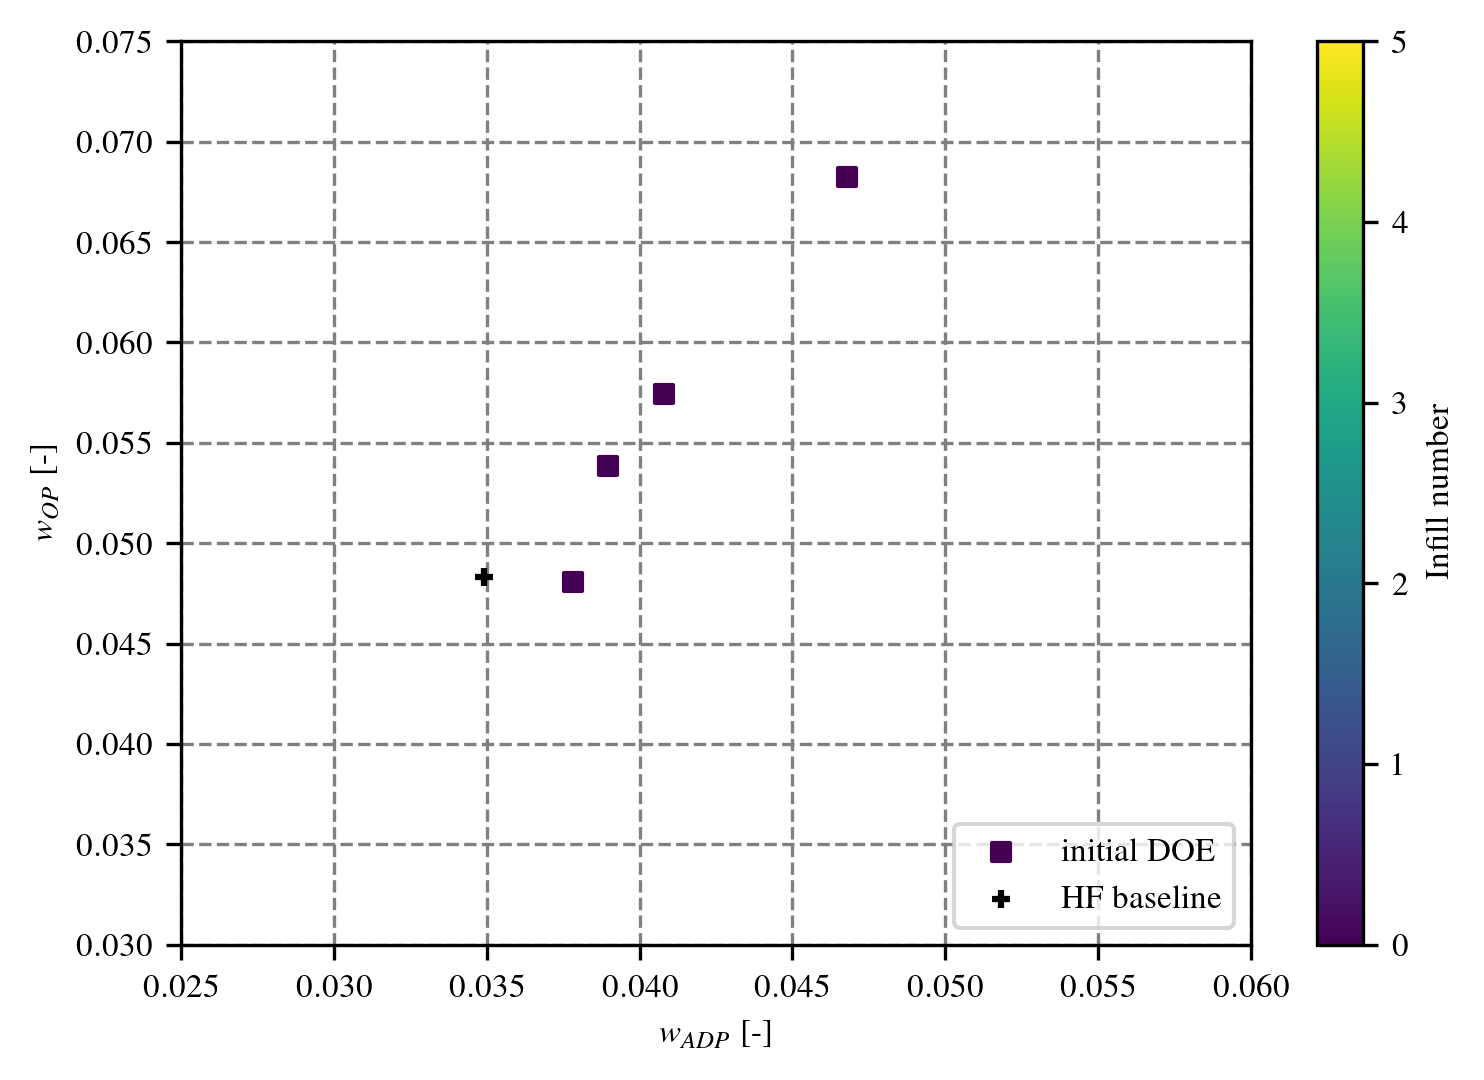

In [ ]:
vmin = 0
vmax = infill_size

fig, ax = plt.subplots(figsize=(5.2, 3.64))
# cmap
cmap = plt.get_cmap("viridis")
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
colors = np.arange(1,vmax+1)
size = 20
initial_value = 0
initial_color = cmap(norm(initial_value))
# initial DOE and baseline
ax.scatter(ar1_y_hf[:doe_size, 0], ar1_y_hf[:doe_size, 1], marker='s', color=initial_color, s=size, label="initial DOE")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="+", color="k", s=size, label="HF baseline")
# Axes settings
ax.set_axisbelow(True)
ax.grid(True, color="grey", linestyle="dashed")
ax.set_ylim(0.030, 0.075)
ax.set_xlim(0.025, 0.060)
# Create a dummy ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Infill number')
# legend
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_1.pdf"), bbox_inches="tight")

with Infills

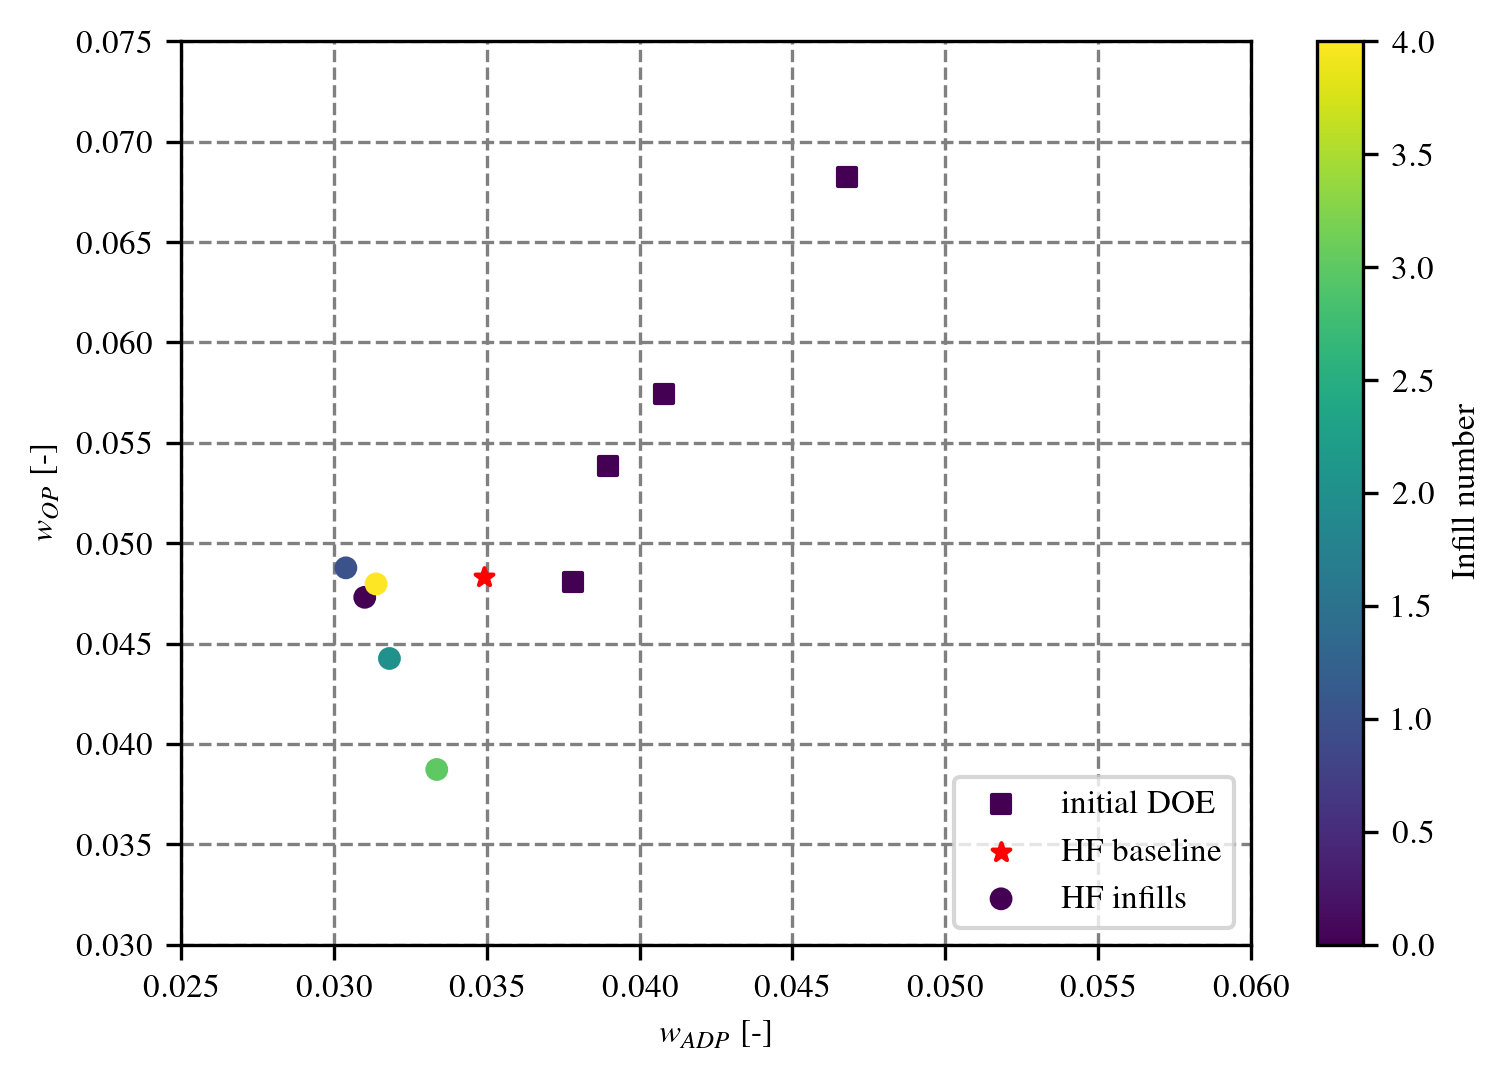

In [72]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))
# initial DOE and baseline
ax.scatter(ar1_y_hf[:doe_size, 0], ar1_y_hf[:doe_size, 1], marker='s', color=initial_color, s=size, label="initial DOE")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", color="r", s=size, label="HF baseline")
# infills
sc = ax.scatter(ar1_y_hf[doe_size:, 0], ar1_y_hf[doe_size:, 1], marker='o', c=colors, cmap=cmap, s=size, label="HF infills")
# Axes settings
ax.set_axisbelow(True)
ax.grid(True, color="grey", linestyle="dashed")
ax.set_ylim(0.030, 0.075)
ax.set_xlim(0.025, 0.060)
# Create a dummy ScalarMappable for the colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Infill number')
# legend
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_2.pdf"), bbox_inches="tight")

Pareto

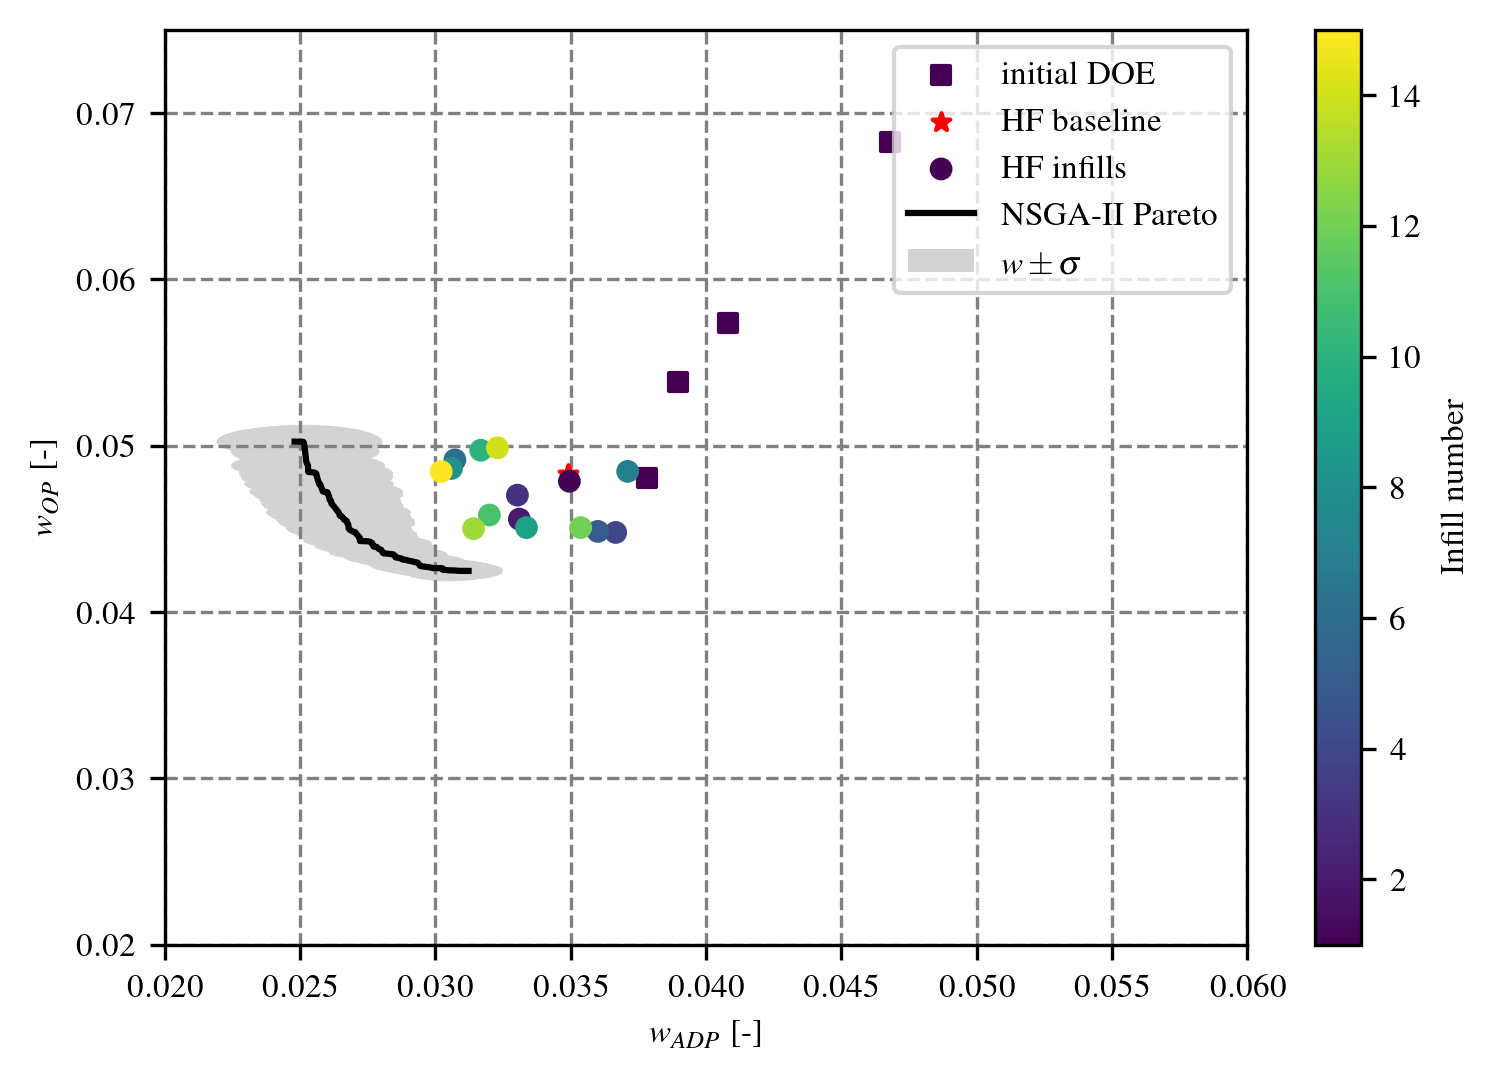

In [40]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))
# initial DOE and baseline
ax.scatter(ar1_y_hf[:doe_size, 0], ar1_y_hf[:doe_size, 1], marker='s', color=initial_color, s=size, label="initial DOE")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", color="r", s=size, label="HF baseline")
# infills
sc = ax.scatter(ar1_y_hf[doe_size:, 0], ar1_y_hf[doe_size:, 1], marker='o', c=colors, cmap=cmap, s=size, label="HF infills")
# Pareto
ax.plot(ar1_pareto_pred[:, 0], ar1_pareto_pred[:, 1], color="k", label="NSGA-II Pareto")
# standard deviation
# Plot error ellipses
for num, (xi, yi, xe, ye) in enumerate(zip(ar1_pareto_pred[:, 0], ar1_pareto_pred[:, 1], w_adp_std[:, 0], w_op_std[:, 0])):
    ellipse = Ellipse((xi, yi), width=2*xe, height=2*ye, facecolor='lightgray', edgecolor='none', label="$w \\pm \\sigma$" if num == 0 else "", zorder=-1)
    ax.add_patch(ellipse)
# Axes settings
ax.set_axisbelow(True)
ax.grid(True, color="grey", linestyle="dashed")
ax.set_ylim(0.020, 0.075)
ax.set_xlim(0.020, 0.060)
# Create a dummy ScalarMappable for the colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Infill number')
# legend
ax.legend()
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_3.pdf"), bbox_inches="tight")

Pareto + recomputed

In [ ]:
# Pareto recomputed
X_recomp = np.loadtxt("../examples/LRN-CASCADE/cascade_musicaa_base/output_nsga_opt/fitnesses.txt")
nsga_idx = 80

fig, ax = plt.subplots(figsize=(5.2, 3.64))
# initial DOE and baseline
ax.scatter(ar1_y_hf[:vmax - 1, 0], ar1_y_hf[:vmax - 1, 1], marker='s', color=initial_color, s=size, label="initial DOE")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", color="r", s=size, label="HF baseline")
# infills
sc = ax.scatter(ar1_y_hf[vmax:, 0], ar1_y_hf[vmax:, 1], marker='o', c=colors, cmap=cmap, s=size, label="HF infills")
# Pareto
ax.plot(ar1_pareto_pred[:, 0], ar1_pareto_pred[:, 1], color="k", label="NSGA-II Pareto")
ax.scatter(ar1_pareto_pred[nsga_idx, 0], ar1_pareto_pred[nsga_idx, 1], marker="o", s=size//2, color="gray", zorder=10)
# standard deviation
# Plot error ellipses
for num, (xi, yi, xe, ye) in enumerate(zip(ar1_pareto_pred[:, 0], ar1_pareto_pred[:, 1], w_adp_std[:, 0], w_op_std[:, 0])):
    ellipse = Ellipse((xi, yi), width=2*xe, height=2*ye, facecolor='lightgray', edgecolor='none', label="$w \\pm \\sigma$" if num == 0 else "", zorder=-1)
    ax.add_patch(ellipse)
# Axes settings
ax.set_axisbelow(True)
ax.grid(True, color="grey", linestyle="dashed")
# ax.set_ylim(0.030, 0.075)
ax.set_xlim(0.025, 0.060)
# Create a dummy ScalarMappable for the colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Infill number')
# legend
ax.legend()
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_4.pdf"), bbox_inches="tight")

FileNotFoundError: ../examples/LRN-CASCADE/cascade_musicaa_base/output_nsga_opt/fitnesses.txt not found.

In [ ]:
print("predicted optimal", ar1_pareto_pred[nsga_idx, 0], ar1_pareto_pred[nsga_idx, 1])
print("computed optimal", X_recomp[0], X_recomp[1])

predicted optimal 0.030850479976538933 0.04439961136022702
computed optimal 0.0315776973695086 0.04480354927949455


LF optimal

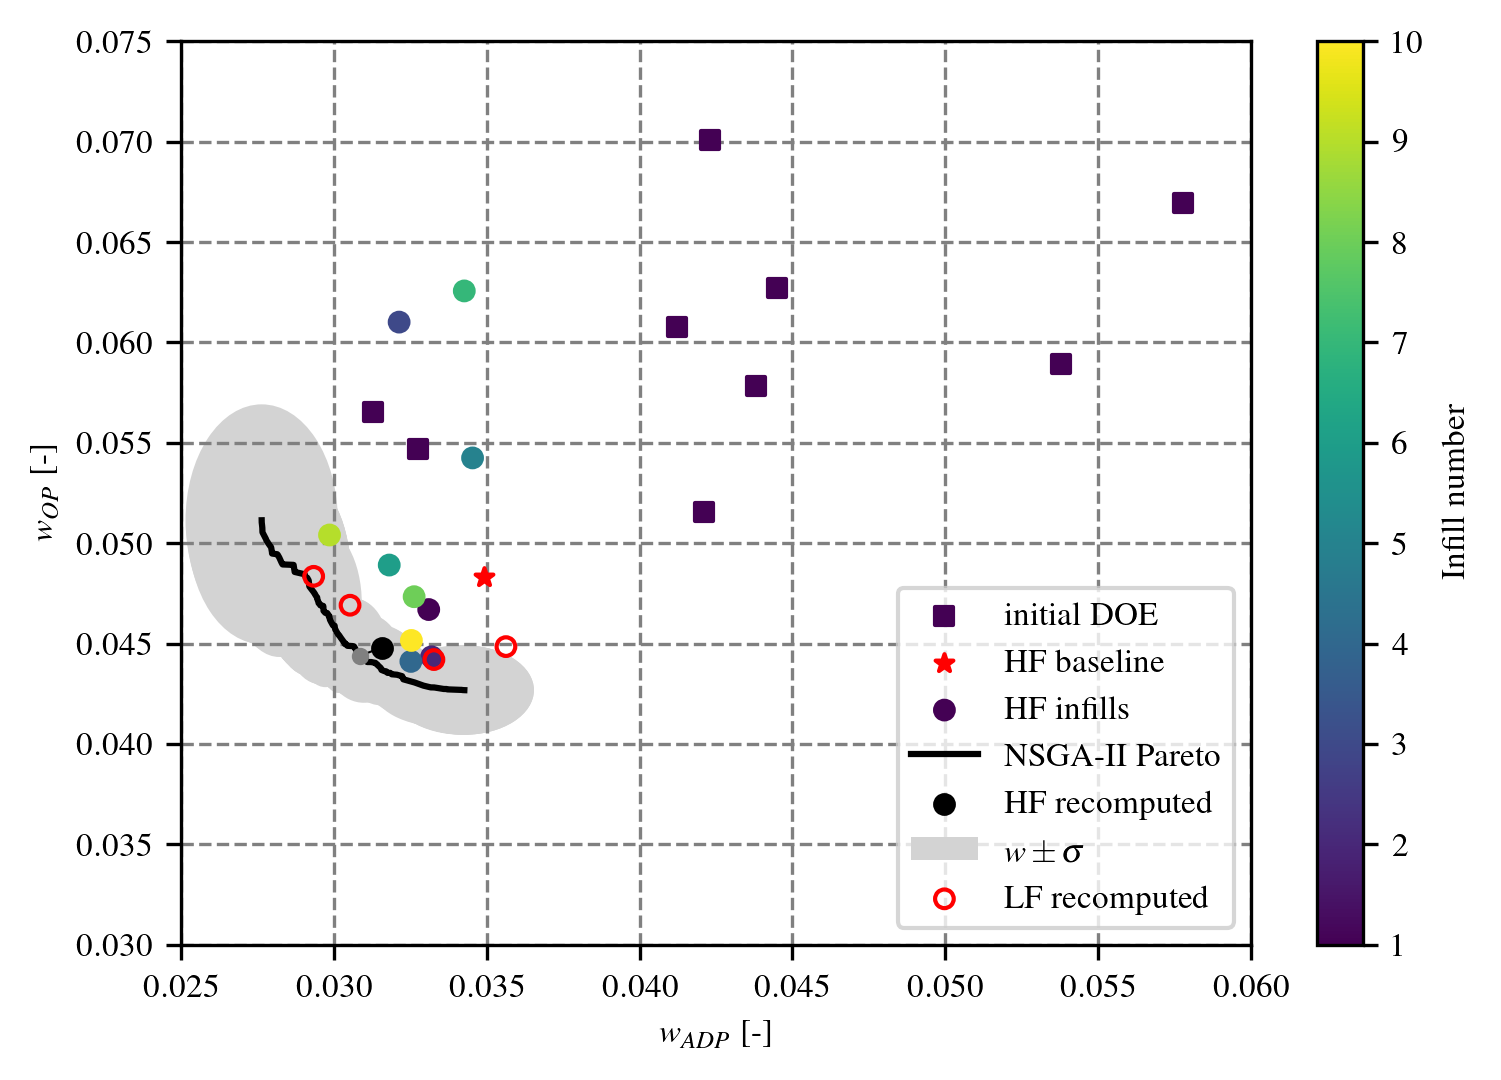

In [ ]:
X_lf_recomp = np.loadtxt("../examples/LRN-CASCADE/cascade_musicaa_base/output_lf_opt/fitnesses.txt")

fig, ax = plt.subplots(figsize=(5.2, 3.64))
# initial DOE and baseline
ax.scatter(ar1_y_hf[:vmax - 1, 0], ar1_y_hf[:vmax - 1, 1], marker='s', color=initial_color, s=size, label="initial DOE")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", color="r", s=size, label="HF baseline")
# infills
sc = ax.scatter(ar1_y_hf[vmax:, 0], ar1_y_hf[vmax:, 1], marker='o', c=colors, cmap=cmap, s=size, label="HF infills")
# Pareto
ax.plot(ar1_pareto_pred[:, 0], ar1_pareto_pred[:, 1], color="k", label="NSGA-II Pareto")
ax.plot([ar1_pareto_pred[nsga_idx, 0], X_recomp[0]], [ar1_pareto_pred[nsga_idx, 1], X_recomp[1]], color="k", linewidth=0.5)
ax.scatter(ar1_pareto_pred[nsga_idx, 0], ar1_pareto_pred[nsga_idx, 1], marker="o", s=size//2, color="gray", zorder=10)
ax.scatter(X_recomp[0], X_recomp[1], marker="o", color="k", s=size, label="HF recomputed", zorder=10)
# standard deviation
# Plot error ellipses
for num, (xi, yi, xe, ye) in enumerate(zip(ar1_pareto_pred[:, 0], ar1_pareto_pred[:, 1], w_adp_std[:, 0], w_op_std[:, 0])):
    ellipse = Ellipse((xi, yi), width=2*xe, height=2*ye, facecolor='lightgray', edgecolor='none', label="$w \\pm \\sigma$" if num == 0 else "", zorder=-1)
    ax.add_patch(ellipse)
# lf optimal
ax.scatter(X_lf_recomp[:, 0], X_lf_recomp[:, 1], marker="o", color="r", facecolors="none", s=size, label="LF recomputed", zorder=10)
# Axes settings
ax.set_axisbelow(True)
ax.grid(True, color="grey", linestyle="dashed")
ax.set_ylim(0.030, 0.075)
ax.set_xlim(0.025, 0.060)
# Create a dummy ScalarMappable for the colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Infill number')
# legend
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_opt.pdf"), bbox_inches="tight")

Profiles
NSGA-II

In [ ]:
opt_idx = np.where(np.all(ar1_pareto_pred[nsga_idx] == ar1_pred_fit, axis=1))[0][0]
print(f"best predicted candidate: {ar1_pareto_pred[nsga_idx]}, {ar1_pareto_pred_cand[nsga_idx]}")
print(f"best predicted candidate from gen {opt_idx // pop_size} cand {opt_idx % pop_size}\n")
# np.savetxt("nsga_opt_candidates.txt", np.atleast_2d(ar1_pred_cand[opt_idx]))

best predicted candidate: [0.03085048 0.04439961], [ 0.02079848 -0.05833761 -0.03469499 -0.04588835 -1.20148339]
best predicted candidate from gen 35 cand 6



In [ ]:
nsga_blade = get_profile(ar1_pred_dir, opt_idx)

LF optimal

In [ ]:
# mixed-out loss results
lf_dir = "../examples/LRN-CASCADE/cascade_wolf_base/output_g50_c20_pod"
lf_cand, lf_fit = get_cand_fit(lf_dir)
lf_pareto = compute_pareto(lf_fit[:, 0], lf_fit[:, 1])

In [ ]:
lf_ADP_cand_idx, lf_OP_cand_idx, lf_cand_idx = get_best_candidates_idx(lf_fit, lf_pareto, 2)

lf_ADP_target = lf_fit[lf_ADP_cand_idx, :]
lf_OP_target = lf_fit[lf_OP_cand_idx, :]
lf_comp_target = lf_fit[lf_cand_idx, :]

lf_opt = np.vstack([lf_ADP_target, lf_OP_target, lf_comp_target])

lf_opt_cand = [get_profile("../examples/LRN-CASCADE/cascade_wolf_base/output_g50_c20_pod", idx) * 1e-3 for idx in [lf_ADP_cand_idx, lf_OP_cand_idx] + lf_cand_idx]

best ADP candidates 790: [0.0414972  0.06808112]
best candidate from gen 39 cand 10

best OP candidates 518: [0.04993426 0.06157421]
best candidate from gen 25 cand 18

best compromise candidates 658: [0.04426915 0.06522716]
best candidate from gen 32 cand 18

best compromise candidates 783: [0.04623873 0.06195759]
best candidate from gen 39 cand 3



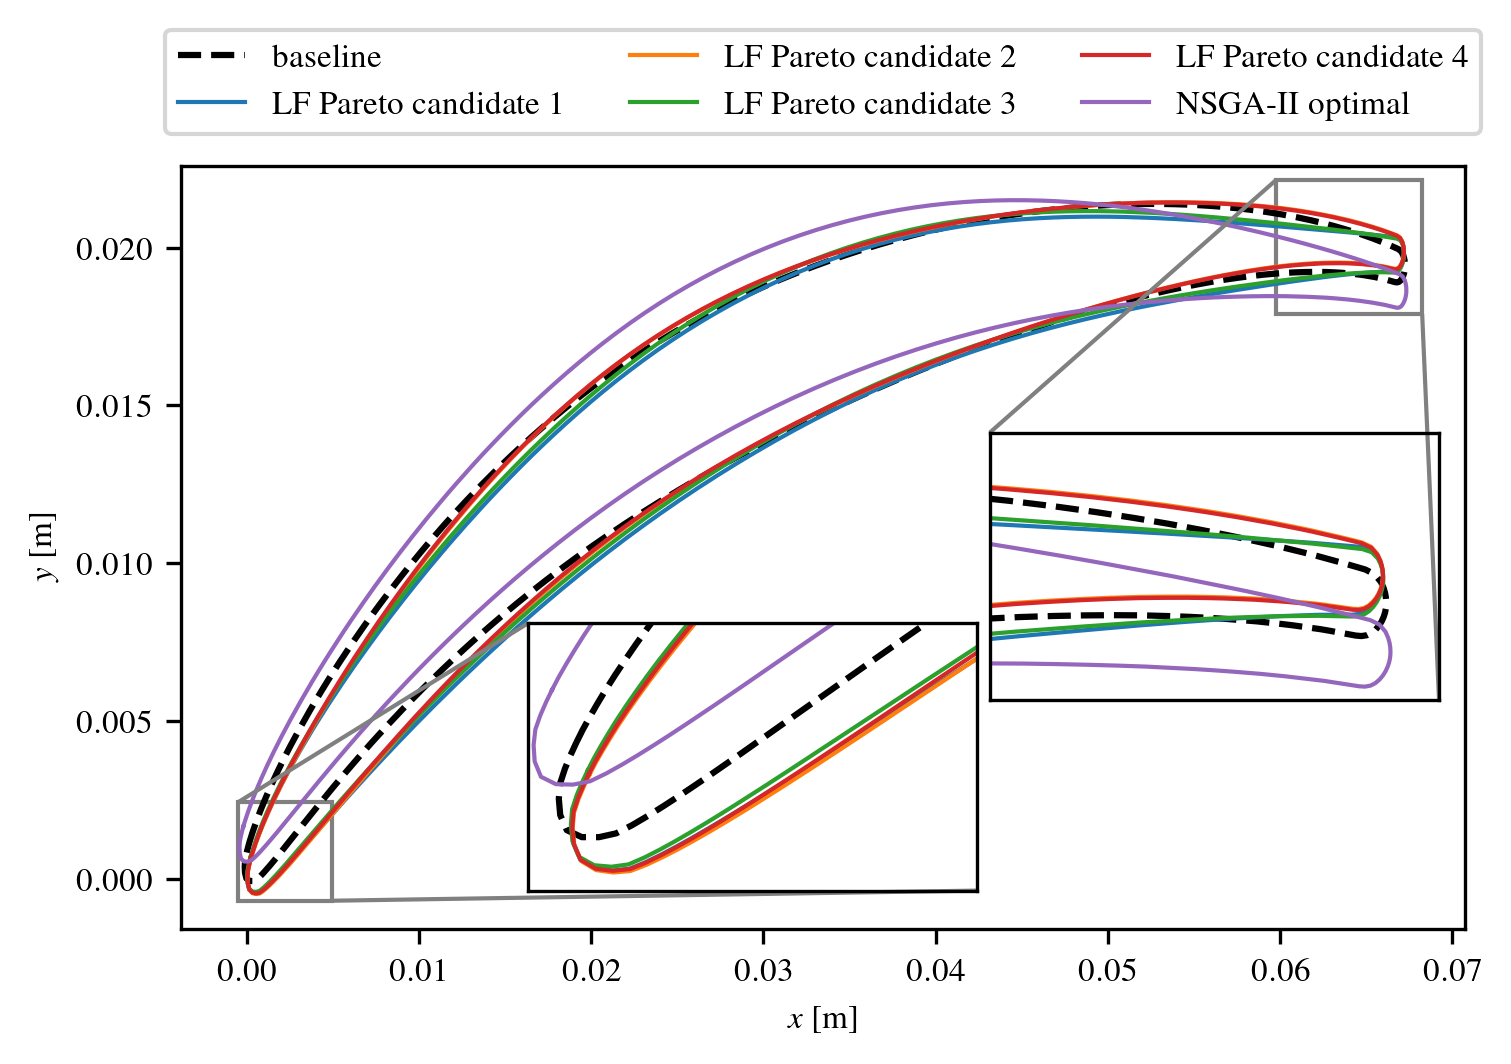

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))

Delta = 0.0025

# baseline
ax.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed", label="baseline")
for num, pro in enumerate(lf_opt_cand):
    ax.plot(pro[:, 0], pro[:, 1], linewidth=1, label=f"LF Pareto candidate {num + 1}")
ax.plot(nsga_blade[:, 0], nsga_blade[:, 1], linewidth=1, label=f"NSGA-II optimal")
ax.set(xlabel='$x$ [m]', ylabel='$y$ [m]')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2),  ncol=3)

# === Leading Edge Inset ===
# axins1 = inset_axes(ax, width="30%", height="30%", loc="lower center", borderpad=2)
axins1 = ax.inset_axes([0.27, 0.05, 0.35, 0.35])
axins1.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed")
for num, pro in enumerate(lf_opt_cand):
    axins1.plot(pro[:, 0], pro[:, 1], linewidth=1)
axins1.plot(nsga_blade[:, 0], nsga_blade[:, 1], linewidth=1)
axins1.set_xlim(min(baseline[:, 0]) - 0.15 * Delta, min(baseline[:, 1]) + 2 * Delta)
axins1.set_ylim(min(baseline[:, 1]) - 0.25 * Delta, min(baseline[:, 1]) + Delta)
axins1.set_xticks([])
axins1.set_yticks([])
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="0.5")

# === Trailing Edge Inset ===
# axins2 = inset_axes(ax, width="30%", height="30%", loc="center right", borderpad=2)
axins2 = ax.inset_axes([0.63, 0.3, 0.35, 0.35])
axins2.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed")
for num, pro in enumerate(lf_opt_cand):
    axins2.plot(pro[:, 0], pro[:, 1], linewidth=1)
axins2.plot(nsga_blade[:, 0], nsga_blade[:, 1], linewidth=1)

axins2.set_xlim(max(baseline[:, 0]) - 3 * Delta, max(baseline[:, 0]) + 0.4 * Delta)
axins2.set_ylim(max(baseline[:, 1]) - 1.4 * Delta, max(baseline[:, 1]) + 0.3 * Delta)
axins2.set_xticks([])
axins2.set_yticks([])
mark_inset(ax, axins2, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_pro.pdf"), bbox_inches="tight")
plt.show()

NSGA-II Pareto front profiles

In [ ]:
ADP_cand_idx, OP_cand_idx, cand_idx = get_best_candidates_idx(ar1_pred_fit, ar1_pareto_pred, 10)

ADP_target = ar1_pred_fit[ADP_cand_idx, :]
OP_target = ar1_pred_fit[OP_cand_idx, :]
comp_target = ar1_pred_fit[cand_idx, :]

nsga_opt_cand = [get_profile("../examples/LRN-CASCADE/cascade_musicaa_mf/output_nsgaii", idx) for idx in [ADP_cand_idx, OP_cand_idx] + cand_idx]

best ADP candidates 971: [0.02763544 0.05114154]
best candidate from gen 48 cand 11

best OP candidates 883: [0.03426734 0.04268088]
best candidate from gen 44 cand 3

best compromise candidates 994: [0.02783079 0.05004973]
best candidate from gen 49 cand 14

best compromise candidates 928: [0.02828806 0.04902748]
best candidate from gen 46 cand 8

best compromise candidates 330: [0.02904475 0.04845179]
best candidate from gen 16 cand 10

best compromise candidates 932: [0.02936537 0.04750786]
best candidate from gen 46 cand 12

best compromise candidates 272: [0.02971617 0.04653355]
best candidate from gen 13 cand 12

best compromise candidates 569: [0.0301445  0.04544281]
best candidate from gen 28 cand 9

best compromise candidates 414: [0.0306562  0.04485969]
best candidate from gen 20 cand 14

best compromise candidates 906: [0.03141476 0.04396464]
best candidate from gen 45 cand 6

best compromise candidates 990: [0.03223306 0.04337727]
best candidate from gen 49 cand 10

best co

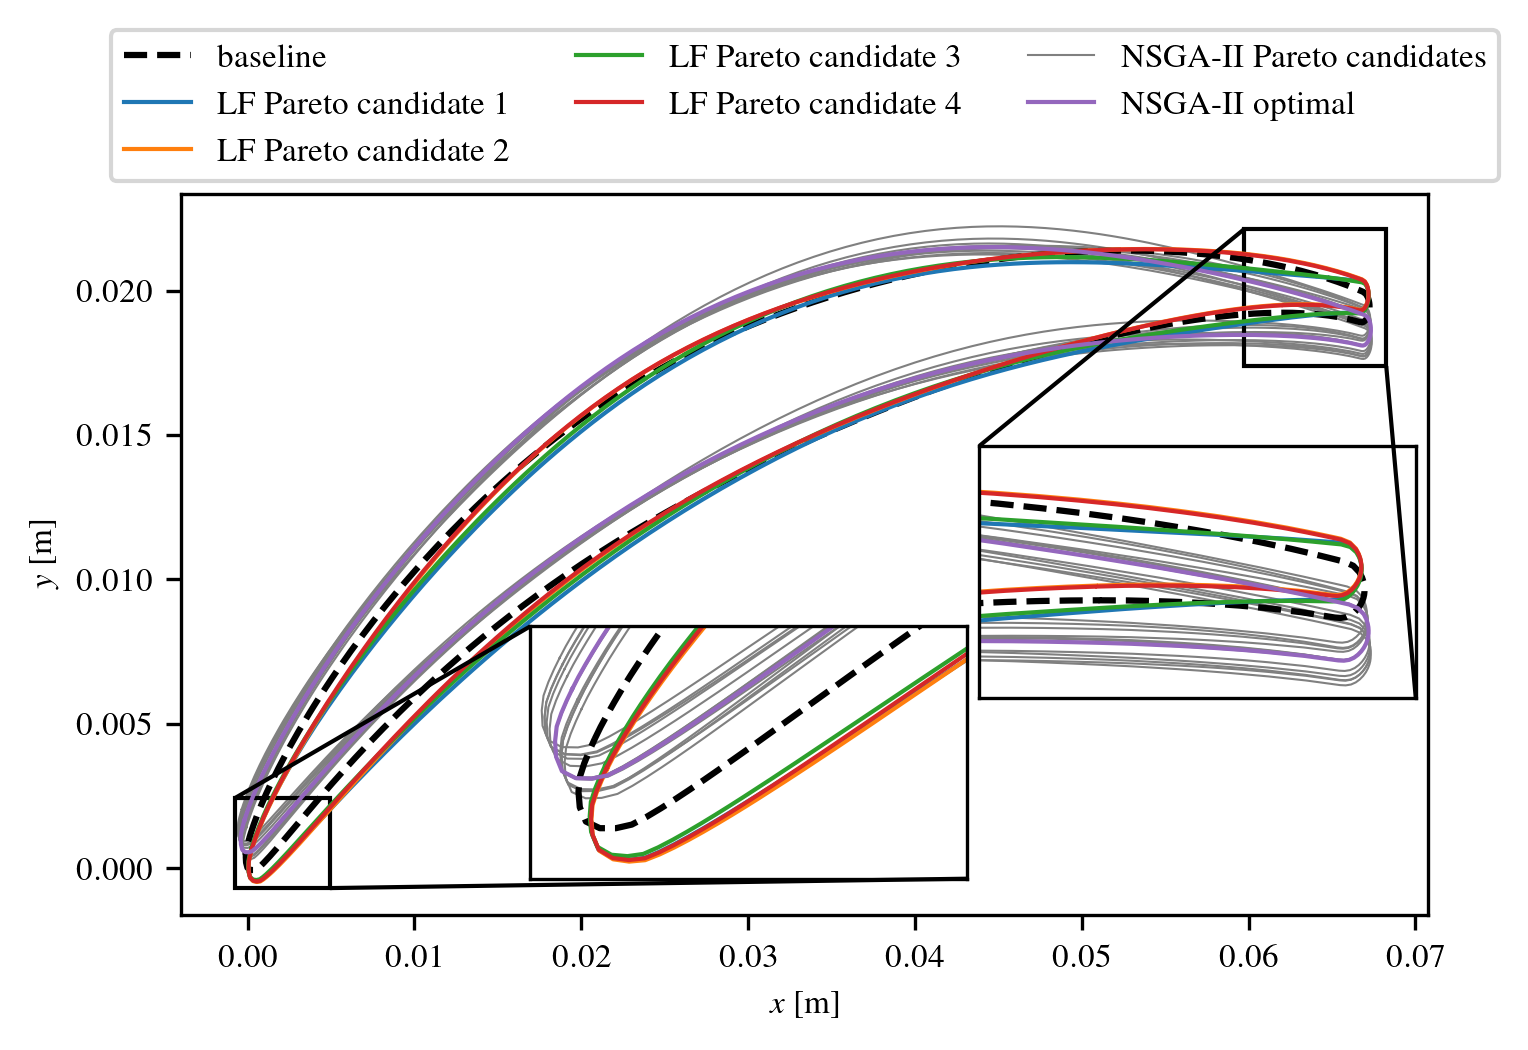

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))

Delta = 0.0025

# baseline
ax.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed", label="baseline")
for num, pro in enumerate(lf_opt_cand):
    ax.plot(pro[:, 0], pro[:, 1], linewidth=1, label=f"LF Pareto candidate {num + 1}")
for num, pro in enumerate(nsga_opt_cand):
    ax.plot(pro[:, 0], pro[:, 1], linewidth=0.5, color="gray", label=f"NSGA-II Pareto candidates" if num == 0 else "", zorder=-10)
ax.plot(nsga_blade[:, 0], nsga_blade[:, 1], linewidth=1, label=f"NSGA-II optimal")
ax.set(xlabel='$x$ [m]', ylabel='$y$ [m]')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),  ncol=3)

# === Leading Edge Inset ===
# axins1 = inset_axes(ax, width="30%", height="30%", loc="lower center", borderpad=2)
axins1 = ax.inset_axes([0.28, 0.05, 0.35, 0.35])
axins1.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed")
for num, pro in enumerate(lf_opt_cand):
    axins1.plot(pro[:, 0], pro[:, 1], linewidth=1)
axins1.plot(nsga_blade[:, 0], nsga_blade[:, 1], linewidth=1)
for num, pro in enumerate(nsga_opt_cand):
    axins1.plot(pro[:, 0], pro[:, 1], linewidth=0.5, color="gray", zorder=-10)
axins1.set_xlim(min(baseline[:, 0]) - 0.25 * Delta, min(baseline[:, 1]) + 2 * Delta)
axins1.set_ylim(min(baseline[:, 1]) - 0.25 * Delta, min(baseline[:, 1]) + Delta)
axins1.set_xticks([])
axins1.set_yticks([])
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="k")

# === Trailing Edge Inset ===
# axins2 = inset_axes(ax, width="30%", height="30%", loc="center right", borderpad=2)
axins2 = ax.inset_axes([0.64, 0.3, 0.35, 0.35])
axins2.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed")
for num, pro in enumerate(lf_opt_cand):
    axins2.plot(pro[:, 0], pro[:, 1], linewidth=1)
axins2.plot(nsga_blade[:, 0], nsga_blade[:, 1], linewidth=1)
for num, pro in enumerate(nsga_opt_cand):
    axins2.plot(pro[:, 0], pro[:, 1], linewidth=0.5, color="gray", zorder=-10)

axins2.set_xlim(max(baseline[:, 0]) - 3 * Delta, max(baseline[:, 0]) + 0.4 * Delta)
axins2.set_ylim(max(baseline[:, 1]) - 1.6 * Delta, max(baseline[:, 1]) + 0.3 * Delta)
axins2.set_xticks([])
axins2.set_yticks([])
mark_inset(ax, axins2, loc1=2, loc2=4, fc="none", ec="k")

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "ar1_pareto_pro.pdf"), bbox_inches="tight")
plt.show()

HF design space

In [ ]:
n_features = ar1_x_hf.shape[1]
labels=['$\\tilde{x}_1$', '$\\tilde{x}_2$', '$\\tilde{x}_3$', '$\\tilde{x}_4$', '$\\alpha$']

X_lf_recomp = np.loadtxt("../examples/LRN-CASCADE/cascade_musicaa_base/output_lf_opt/candidates.txt")
Y_lf_recomp = np.loadtxt("../examples/LRN-CASCADE/cascade_musicaa_base/output_lf_opt/fitnesses.txt")

 /tmp/ipykernel_48153/1858556158.py:10: UserWarning:*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
 /tmp/ipykernel_48153/1858556158.py:10: UserWarning:*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
 /tmp/ipykernel_48153/1858556158.py:10: UserWarning:*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument o

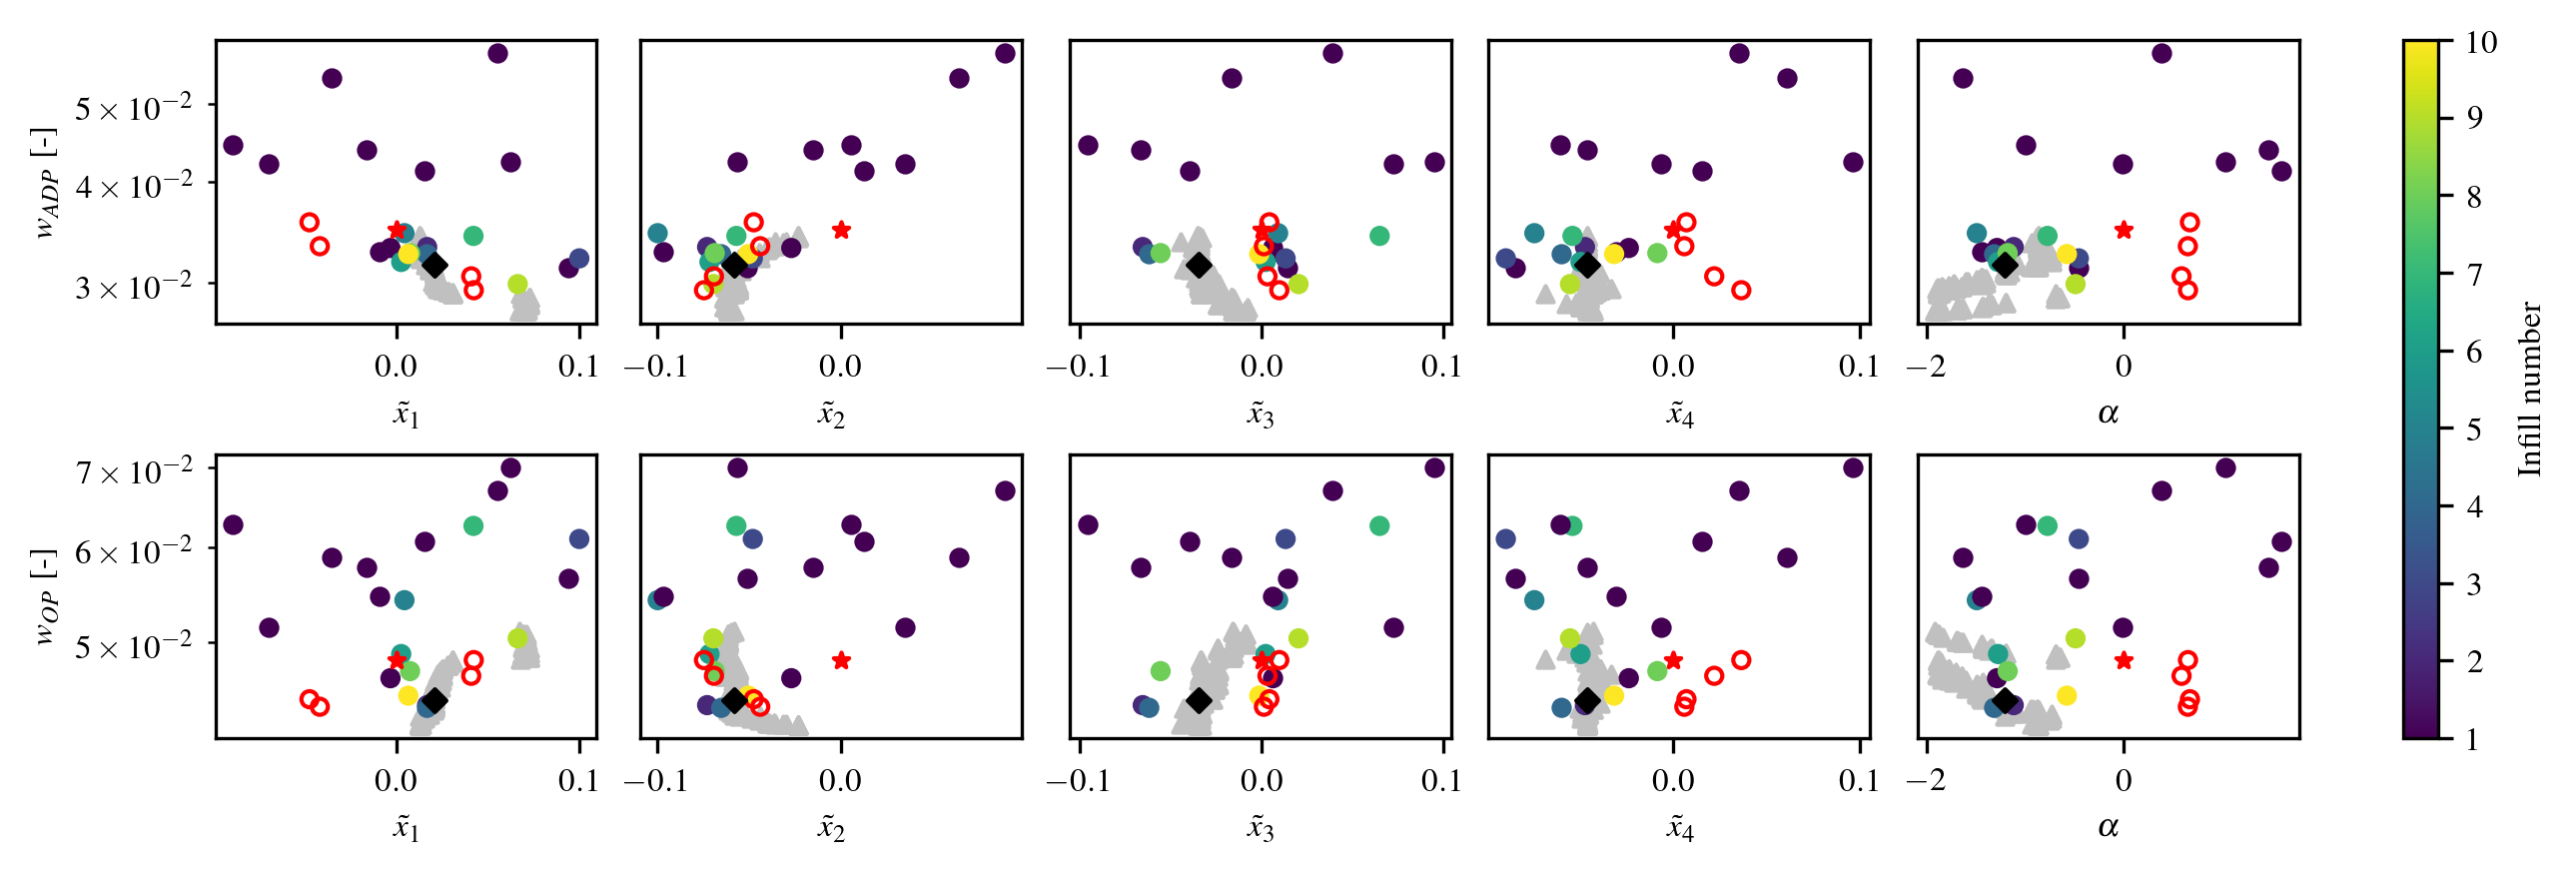

In [ ]:
# Plot
fig, axes = plt.subplots(2, n_features, figsize=(8.5, 2.8), constrained_layout=True)

for i in range(n_features):
    ax = axes[0, i]
    ax.set_yscale('log')
    if i == 0:
        ax.set_ylabel('$w_{ADP}$ [-]')
    ax.scatter(0, bsl_w_ADP, marker="*", color="r", s=15, zorder=10)
    ax.scatter(ar1_x_hf[:9, i], ar1_y_hf[:9, 0], c=initial_color, s=15)
    ax.scatter(ar1_x_hf[10:, i], ar1_y_hf[10:, 0], c=colors, s=15)
    ax.scatter(ar1_pareto_pred_cand[:, i], ar1_pareto_pred[:, 0], marker="^", c="silver", s=15, zorder=-10)
    ax.scatter(X_lf_recomp[:, i], Y_lf_recomp[:, 0], facecolors="none", edgecolors="r",  s=15)
    ax.scatter(ar1_pareto_pred_cand[nsga_idx, i], X_recomp[0], marker="D", c="k", s=15)
    ax.set_xlabel(labels[i])
    if i != 0:
        ax.yaxis.minorticks_off()
        ax.set_yticklabels([])
        ax.tick_params(left=False)
        ax.yaxis.set_major_locator(plt.NullLocator())
for i in range(n_features):
    ax = axes[1, i]
    ax.set_yscale('log')
    if i == 0:
        ax.set_ylabel('$w_{OP}$ [-]')
    ax.scatter(0, bsl_w_OP, marker="*", color="r", s=15, zorder=10)
    ax.scatter(ar1_x_hf[:9, i], ar1_y_hf[:9, 1], c=initial_color, s=15, zorder=10)
    ax.scatter(ar1_x_hf[10:, i], ar1_y_hf[10:, 1], c=colors, s=15)
    ax.scatter(ar1_pareto_pred_cand[:, i], ar1_pareto_pred[:, 1], marker="^", c="silver", s=15, zorder=-10)
    ax.scatter(X_lf_recomp[:, i], Y_lf_recomp[:, 1], facecolors="none", edgecolors="r", s=15)
    ax.scatter(ar1_pareto_pred_cand[nsga_idx, i], X_recomp[1], marker="D", c="k", s=15)
    ax.set_xlabel(labels[i])
    if i != 0:
        ax.yaxis.minorticks_off()
        ax.set_yticklabels([])
        ax.tick_params(left=False)
        ax.yaxis.set_major_locator(plt.NullLocator())

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.05)
cbar.set_label('Infill number')
plt.savefig(os.path.join(os.getcwd(), "hf_space.pdf"), bbox_inches="tight")
plt.show()

---
Best predicted candidate

In [ ]:
X_recomp

array([0.0315777 , 0.04480355])